# Copper wire production line analysis

In [2]:
import pandas as pd

In [18]:
data = pd.read_csv('./Cable-Production-Line-Dataset.csv')

In [19]:
data.keys()

Index(['Machine', 'Shift', 'Operator', 'Date', 'Cable Failures',
       'Cable Failure Downtime', 'Other Failures', 'Other Failure Downtime'],
      dtype='object')

In [20]:
data.head()

,Machine,Shift,Operator,Date,Cable Failures,Cable Failure Downtime,Other Failures,Other Failure Downtime
0,1,A,1,11/6/2020,1,35,1,30
1,2,A,2,11/6/2020,1,10,3,150
2,2,B,3,11/6/2020,2,40,2,110
3,2,A,2,11/7/2020,5,120,1,80
4,2,B,3,11/7/2020,2,40,1,35


In [27]:
data['Total Failures'] = data['Cable Failures'] + data['Other Failures']
data['Total Downtime'] = data['Cable Failure Downtime'] + data['Other Failure Downtime']

data['Date'] = pd.to_datetime(data['Date'])

data.head()

,Machine,Shift,Operator,Date,Cable Failures,Cable Failure Downtime,Other Failures,Other Failure Downtime,Total Failures,Total Downtime
0,1,A,1,2020-11-06,1,35,1,30,2,65
1,2,A,2,2020-11-06,1,10,3,150,4,160
2,2,B,3,2020-11-06,2,40,2,110,4,150
3,2,A,2,2020-11-07,5,120,1,80,6,200
4,2,B,3,2020-11-07,2,40,1,35,3,75


In [28]:
data.describe()

,Machine,Operator,Date,Cable Failures,Cable Failure Downtime,Other Failures,Other Failure Downtime,Total Failures,Total Downtime
count,149.000000,149.000000,149,149.000000,149.000000,149.000000,149.00000,149.000000,149.000000
mean,5.932886,12.946309,2020-11-15 12:14:29.798657792,1.409396,51.442953,0.536913,47.04698,1.946309,98.489933
min,1.000000,1.000000,2020-11-06 00:00:00,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,2.000000,6.000000,2020-11-12 00:00:00,0.000000,0.000000,0.000000,0.00000,1.000000,30.000000
50%,5.000000,12.000000,2020-11-15 00:00:00,1.000000,35.000000,0.000000,0.00000,1.000000,60.000000
75%,8.000000,18.000000,2020-11-19 00:00:00,2.000000,70.000000,1.000000,45.00000,2.000000,120.000000
max,17.000000,32.000000,2020-11-22 00:00:00,6.000000,295.000000,9.000000,690.00000,9.000000,690.000000
std,4.294346,8.659306,NaN,1.325495,56.658935,0.969281,106.39678,1.417960,112.009750


In [29]:
data['Operator'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32])

In [30]:
data['Machine'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17])

<Axes: >

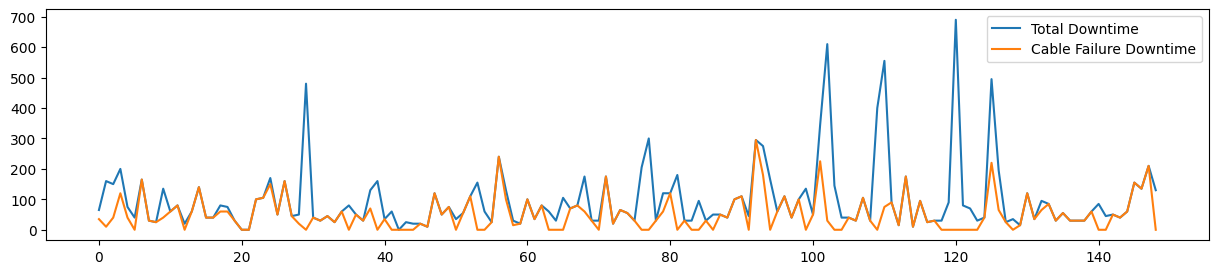

In [35]:
ax = data.plot(y='Total Downtime', figsize=(15,3))
data.plot(ax=ax, y='Cable Failure Downtime')

Text(0, 0.5, 'Downtime')

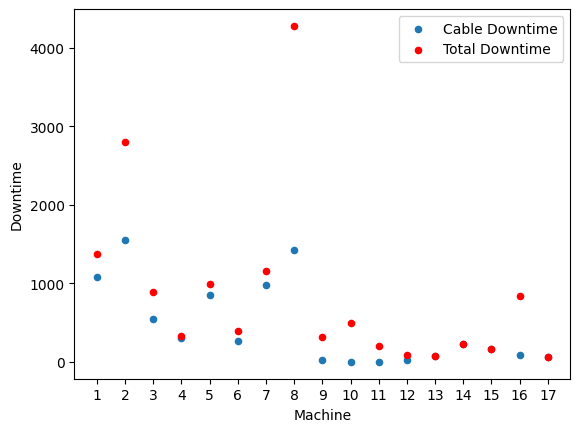

In [161]:
grouped = data.groupby('Machine')[['Total Downtime','Cable Failure Downtime']].sum().reset_index()
ax = grouped.plot(kind='scatter', x='Machine', y='Cable Failure Downtime', xticks=range(1, len(grouped)+1), label='Cable Downtime')
grouped.plot(ax=ax, kind='scatter',  x='Machine', y='Total Downtime', color='r', label='Total Downtime')
ax.set_ylabel('Downtime')